In [96]:


import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [97]:
df = pd.read_csv('https://raw.githubusercontent.com/ingledarshan/upGrad_Darshan/refs/heads/main/pca_data.csv') # Replace it with your path where the data file is stored
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [98]:
df.columns

Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='object')

In [99]:
df.shape

(62184, 11)

In [100]:
df.corr(numeric_only=True)

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
number_people,1.000000,0.550218,-0.162062,-0.173958,-0.048249,0.373327,0.182683,0.335350,-0.097854,0.552049
timestamp,0.550218,1.000000,-0.001793,-0.000509,0.002851,0.184849,0.009551,0.044676,-0.023221,0.999077
day_of_week,-0.162062,-0.001793,1.000000,0.791338,-0.075862,0.011169,-0.011782,-0.004824,0.015559,-0.001914
is_weekend,-0.173958,-0.000509,0.791338,1.000000,-0.031899,0.020673,-0.016646,-0.036127,0.008462,-0.000517
is_holiday,-0.048249,0.002851,-0.075862,-0.031899,1.000000,-0.088527,-0.014858,-0.070798,-0.094942,0.002843
temperature,0.373327,0.184849,0.011169,0.020673,-0.088527,1.000000,0.093242,0.152476,0.063125,0.185121
is_start_of_semester,0.182683,0.009551,-0.011782,-0.016646,-0.014858,0.093242,1.000000,0.209862,-0.137160,0.010091
is_during_semester,0.335350,0.044676,-0.004824,-0.036127,-0.070798,0.152476,0.209862,1.000000,0.096556,0.045581
month,-0.097854,-0.023221,0.015559,0.008462,-0.094942,0.063125,-0.137160,0.096556,1.000000,-0.023624
hour,0.552049,0.999077,-0.001914,-0.000517,0.002843,0.185121,0.010091,0.045581,-0.023624,1.000000


In [101]:
# The temperture given here is in fahrenheit. We will convert it into Celsius using the formula Celsius=(Fahrenheit-32) (5/9)
df['temperature'] = (df['temperature'] - 32) * 5/9
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,22.088889,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,22.088889,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,22.088889,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,22.088889,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,22.088889,0,0,8,17


In [102]:
# Lets separate the features and the target variable. The target variable is 'number_people' and the rest of the columns are features.
X = df.drop('number_people', axis=1)
y = df['number_people']

X.head()

,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,2015-08-14 17:00:11-07:00,61211,4,0,0,22.088889,0,0,8,17
1,2015-08-14 17:20:14-07:00,62414,4,0,0,22.088889,0,0,8,17
2,2015-08-14 17:30:15-07:00,63015,4,0,0,22.088889,0,0,8,17
3,2015-08-14 17:40:16-07:00,63616,4,0,0,22.088889,0,0,8,17
4,2015-08-14 17:50:17-07:00,64217,4,0,0,22.088889,0,0,8,17


In [103]:
y

0        37
1        45
2        40
3        44
4        45
         ..
62179    23
62180    21
62181    25
62182    18
62183    23
Name: number_people, Length: 62184, dtype: int64

In [104]:
# Drop the 'date' and 'timestamp' columns as they are not useful for our analysis.
X = X.drop(['date', 'timestamp'], axis=1)
X.head()

,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,4,0,0,22.088889,0,0,8,17
1,4,0,0,22.088889,0,0,8,17
2,4,0,0,22.088889,0,0,8,17
3,4,0,0,22.088889,0,0,8,17
4,4,0,0,22.088889,0,0,8,17


Text(0.5, 1.0, 'Correlation between different fearures')

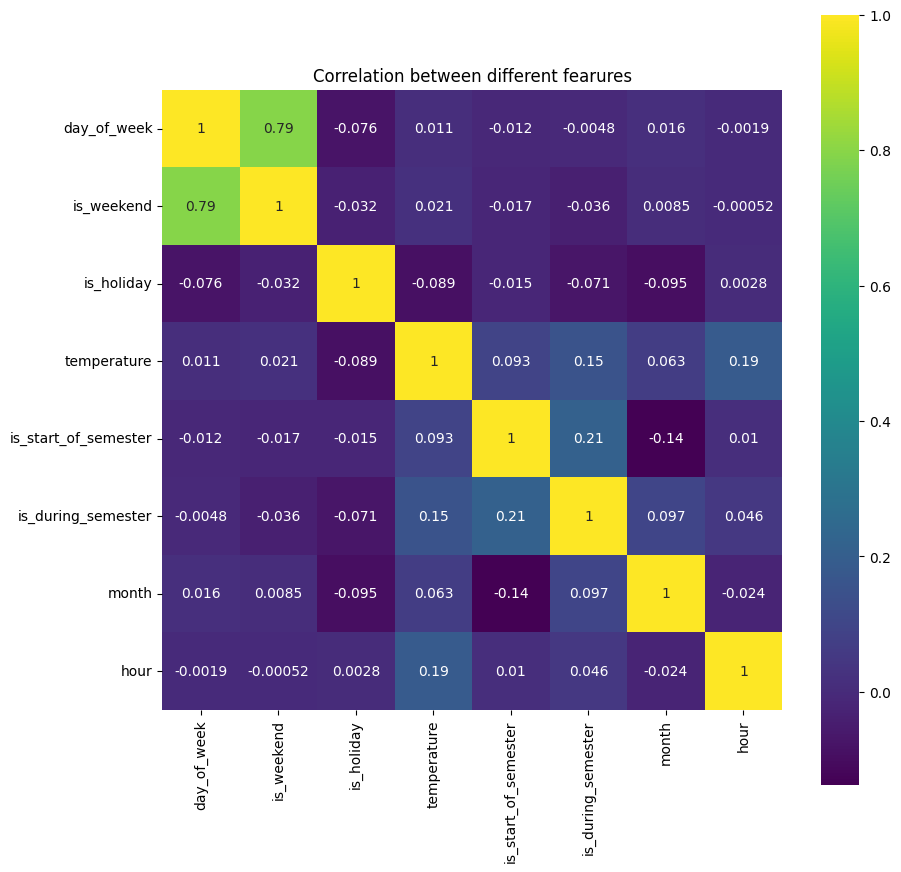

In [105]:
correlation = X.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(correlation, vmax=1, square=True,annot=True,cmap='viridis')

plt.title('Correlation between different fearures')

In [106]:
# Lets remove "is_weekend" since it is highly correlated with "day_of_week". 
X = X.drop('is_weekend', axis=1)
X.head()

,day_of_week,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,4,0,22.088889,0,0,8,17
1,4,0,22.088889,0,0,8,17
2,4,0,22.088889,0,0,8,17
3,4,0,22.088889,0,0,8,17
4,4,0,22.088889,0,0,8,17


In [107]:
num_cols = list(X.columns)
num_cols

['day_of_week',
 'is_holiday',
 'temperature',
 'is_start_of_semester',
 'is_during_semester',
 'month',
 'hour']

In [108]:
# Now lets go fro train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (49747, 7)
X_test shape: (12437, 7)
y_train shape: (49747,)
y_test shape: (12437,)


In [109]:
# Lets apply StandardScaler to standardize the features.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [110]:
X_train.shape, X_test.shape

((49747, 7), (12437, 7))

In [111]:


from sklearn.decomposition import PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [112]:
pca.get_covariance().shape

(7, 7)

In [113]:
pca.get_covariance()

array([[ 1.0000201 , -0.0750416 ,  0.01214031, -0.01286251, -0.00491902,
         0.01379205, -0.00361893],
       [-0.0750416 ,  1.0000201 , -0.0867941 , -0.01469771, -0.07008926,
        -0.09391504,  0.00695272],
       [ 0.01214031, -0.0867941 ,  1.0000201 ,  0.09461548,  0.15079189,
         0.06692114,  0.18388642],
       [-0.01286251, -0.01469771,  0.09461548,  1.0000201 ,  0.20970403,
        -0.13619006,  0.01236309],
       [-0.00491902, -0.07008926,  0.15079189,  0.20970403,  1.0000201 ,
         0.09943499,  0.04196696],
       [ 0.01379205, -0.09391504,  0.06692114, -0.13619006,  0.09943499,
         1.0000201 , -0.02529157],
       [-0.00361893,  0.00695272,  0.18388642,  0.01236309,  0.04196696,
        -0.02529157,  1.0000201 ]])

In [114]:
explained_variance = pca.explained_variance_ratio_
explained_variance
# What is explained_variance_ratio_?
# The explained_variance_ratio_ attribute of the PCA class in scikit-learn represents the proportion of the dataset's variance that is explained by each of the selected principal components. It is an array where each element corresponds to a principal component, and the value indicates how much of the total variance in the data is captured by that component. The sum of all values in explained_variance_ratio_ will be equal to 1 (or 100% when expressed as a percentage), indicating that all the variance in the data is accounted for by the selected components. This information is crucial for understanding how many principal components are needed to capture a desired amount of variance in the dataset.

array([0.19830762, 0.16831592, 0.15214028, 0.14486196, 0.12704011,
       0.11042799, 0.09890611])

In [115]:
# Lets find the sum of the explained variance ratio to find out how much variance is explained by all the principal components together.
explained_variance.sum()

np.float64(0.9999999999999999)

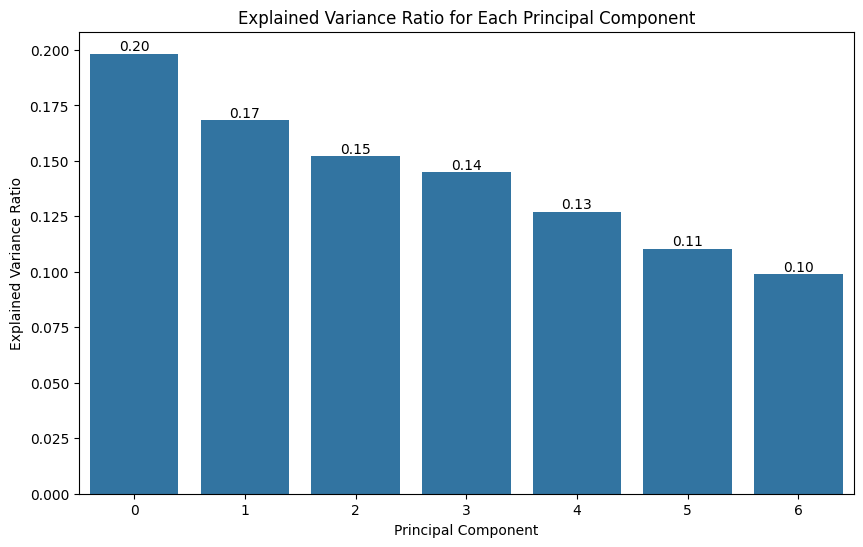

In [116]:

plt.figure(figsize=(10,6))
sns.barplot(x=np.arange(len(explained_variance)), y=explained_variance)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio for Each Principal Component')

plt.text(0, explained_variance[0], f'{explained_variance[0]:.2f}', ha='center', va='bottom')
plt.text(1, explained_variance[1], f'{explained_variance[1]:.2f}', ha='center', va='bottom')
plt.text(2, explained_variance[2], f'{explained_variance[2]:.2f}', ha='center', va='bottom')
plt.text(3, explained_variance[3], f'{explained_variance[3]:.2f}', ha='center', va='bottom')
plt.text(4, explained_variance[4], f'{explained_variance[4]:.2f}', ha='center', va='bottom')
plt.text(5, explained_variance[5], f'{explained_variance[5]:.2f}', ha='center', va='bottom')
plt.text(6, explained_variance[6], f'{explained_variance[6]:.2f}', ha='center', va='bottom')

plt.show()

In [117]:
# Lets look at the cumulative explained variance ratio to see how much variance is explained by the first n principal components together.
cumulative_explained_variance = np.cumsum(explained_variance)
cumulative_explained_variance

array([0.19830762, 0.36662355, 0.51876383, 0.66362579, 0.7906659 ,
       0.90109389, 1.        ])

In [118]:
# Lets create a ML first with all the principal components and then we will create another ML model with only the first 5 principal components to see if there is any difference in the performance of the model. We will use Linear Regression as our ML model.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_all = LinearRegression()
lr_all.fit(X_train_pca, y_train)

y_pred_all_train = lr_all.predict(X_train_pca)
y_pred_all_test = lr_all.predict(X_test_pca)

mse_all_train = mean_squared_error(y_train, y_pred_all_train)
r2_all_train = r2_score(y_train, y_pred_all_train)
mse_all_test = mean_squared_error(y_test, y_pred_all_test)
r2_all_test = r2_score(y_test, y_pred_all_test)

print("Performance of the model with all principal components:")
print("Training MSE:", mse_all_train)
print("Testing MSE:", mse_all_test)
print("Training R2 Score:", r2_all_train)
print("Testing R2 Score:", r2_all_test)

Performance of the model with all principal components:
Training MSE: 255.5269704371173
Testing MSE: 252.4858584533178
Training R2 Score: 0.5031241963878523
Testing R2 Score: 0.5114888608145889


In [119]:

# Lets try Decision Tree Regressor now. 
from sklearn.tree import DecisionTreeRegressor
dt_all = DecisionTreeRegressor(random_state=42)
dt_all.fit(X_train_pca, y_train)

y_pred_dt_all_train = dt_all.predict(X_train_pca)
y_pred_dt_all_test = dt_all.predict(X_test_pca)

mse_dt_all_train = mean_squared_error(y_train, y_pred_dt_all_train)
r2_dt_all_train = r2_score(y_train, y_pred_dt_all_train)
mse_dt_all_test = mean_squared_error(y_test, y_pred_dt_all_test)
r2_dt_all_test = r2_score(y_test, y_pred_dt_all_test)

print("Performance of the Decision Tree Regressor with all principal components:")
print("Training MSE:", mse_dt_all_train)
print("Testing MSE:", mse_dt_all_test)
print("Training R2 Score:", r2_dt_all_train)
print("Testing R2 Score:", r2_dt_all_test)

Performance of the Decision Tree Regressor with all principal components:
Training MSE: 23.04434967443412
Testing MSE: 40.17623785605323
Training R2 Score: 0.9551899365314881
Testing R2 Score: 0.9222667762722506


In [120]:
# Lets also try Random Forest Regressor to see if we can get better performance.
from sklearn.ensemble import RandomForestRegressor
rf_all = RandomForestRegressor(random_state=42)
rf_all.fit(X_train_pca, y_train)

y_pred_rf_all_train = rf_all.predict(X_train_pca)
y_pred_rf_all_test = rf_all.predict(X_test_pca)

mse_rf_all_train = mean_squared_error(y_train, y_pred_rf_all_train)
r2_rf_all_train = r2_score(y_train, y_pred_rf_all_train)
mse_rf_all_test = mean_squared_error(y_test, y_pred_rf_all_test)
r2_rf_all_test = r2_score(y_test, y_pred_rf_all_test)

print("Performance of the Random Forest Regressor with all principal components:")
print("Training MSE:", mse_rf_all_train)
print("Testing MSE:", mse_rf_all_test)
print("Training R2 Score:", r2_rf_all_train)
print("Testing R2 Score:", r2_rf_all_test)

Performance of the Random Forest Regressor with all principal components:
Training MSE: 23.410723053199384
Testing MSE: 38.99795917670601
Training R2 Score: 0.9544775183210554
Testing R2 Score: 0.9245465168622854


In [121]:
# Lets try CatBoost Regressor to see if we can get better performance.
from catboost import CatBoostRegressor
cat_all = CatBoostRegressor(random_state=42, verbose=0)
cat_all.fit(X_train_pca, y_train)

y_pred_cat_all_train = cat_all.predict(X_train_pca)
y_pred_cat_all_test = cat_all.predict(X_test_pca)

mse_cat_all_train = mean_squared_error(y_train, y_pred_cat_all_train)
r2_cat_all_train = r2_score(y_train, y_pred_cat_all_train)
mse_cat_all_test = mean_squared_error(y_test, y_pred_cat_all_test)
r2_cat_all_test = r2_score(y_test, y_pred_cat_all_test)

print("Performance of the CatBoost Regressor with all principal components:")
print("Training MSE:", mse_cat_all_train)
print("Testing MSE:", mse_cat_all_test)
print("Training R2 Score:", r2_cat_all_train)
print("Testing R2 Score:", r2_cat_all_test)

Performance of the CatBoost Regressor with all principal components:
Training MSE: 85.44186490070612
Testing MSE: 96.46358117668511
Training R2 Score: 0.8338570867410396
Testing R2 Score: 0.8133616899607884


In [122]:

from sklearn.decomposition import PCA
pca_5 = PCA(n_components=5)
X_train_pca_5 = pca_5.fit_transform(X_train)
X_test_pca_5 = pca_5.transform(X_test)

# Now we will train the Decision Tree Regressor with the first 5 principal components and see the performance of the model.
dt_5 = DecisionTreeRegressor(random_state=42)
dt_5.fit(X_train_pca_5, y_train)

y_pred_dt_5_train = dt_5.predict(X_train_pca_5)
y_pred_dt_5_test = dt_5.predict(X_test_pca_5)

mse_dt_5_train = mean_squared_error(y_train, y_pred_dt_5_train)
r2_dt_5_train = r2_score(y_train, y_pred_dt_5_train)
mse_dt_5_test = mean_squared_error(y_test, y_pred_dt_5_test)
r2_dt_5_test = r2_score(y_test, y_pred_dt_5_test)

print("Performance of the Decision Tree Regressor with the first 5 principal components:")
print("Training MSE:", mse_dt_5_train)
print("Testing MSE:", mse_dt_5_test)
print("Training R2 Score:", r2_dt_5_train)
print("Testing R2 Score:", r2_dt_5_test)

# Performance of the Decision Tree Regressor with all principal components:
# Training MSE: 23.044349674434116
# Testing MSE: 40.17623785605323
# Training R2 Score: 0.9551899365314881
# Testing R2 Score: 0.9222667762722506

Performance of the Decision Tree Regressor with the first 5 principal components:
Training MSE: 23.04434967443412
Testing MSE: 40.32427470001842
Training R2 Score: 0.9551899365314881
Testing R2 Score: 0.9219803537069242


In [123]:
# The above results are obtained using all the principal components (7 principal components). Now, lets try with only the first 4 principal components to see if there is any difference in the performance of the model.

pca_4 = PCA(n_components=4)
X_train_pca_4 = pca_4.fit_transform(X_train)
X_test_pca_4 = pca_4.transform(X_test)

dt_4 = DecisionTreeRegressor(random_state=42)
dt_4.fit(X_train_pca_4, y_train)

y_pred_dt_4_train = dt_4.predict(X_train_pca_4)
y_pred_dt_4_test = dt_4.predict(X_test_pca_4)

mse_dt_4_train = mean_squared_error(y_train, y_pred_dt_4_train)
r2_dt_4_train = r2_score(y_train, y_pred_dt_4_train)
mse_dt_4_test = mean_squared_error(y_test, y_pred_dt_4_test)
r2_dt_4_test = r2_score(y_test, y_pred_dt_4_test)

print("Performance of the Decision Tree Regressor with the first 4 principal components:")
print("Training MSE:", mse_dt_4_train)
print("Testing MSE:", mse_dt_4_test)
print("Training R2 Score:", r2_dt_4_train)
print("Testing R2 Score:", r2_dt_4_test)



Performance of the Decision Tree Regressor with the first 4 principal components:
Training MSE: 23.04434967443412
Testing MSE: 40.368727140317525
Training R2 Score: 0.9551899365314881
Testing R2 Score: 0.9218943468613008


In [124]:
# The above results are obtained using all the principal components (7 principal components). Now, lets try with only the first 3 principal components to see if there is any difference in the performance of the model.

pca_3 = PCA(n_components=3)
X_train_pca_3 = pca_3.fit_transform(X_train)
X_test_pca_3 = pca_3.transform(X_test)

dt_3 = DecisionTreeRegressor(random_state=42)
dt_3.fit(X_train_pca_3, y_train)

y_pred_dt_3_train = dt_3.predict(X_train_pca_3)
y_pred_dt_3_test = dt_3.predict(X_test_pca_3)

mse_dt_3_train = mean_squared_error(y_train, y_pred_dt_3_train)
r2_dt_3_train = r2_score(y_train, y_pred_dt_3_train)
mse_dt_3_test = mean_squared_error(y_test, y_pred_dt_3_test)
r2_dt_3_test = r2_score(y_test, y_pred_dt_3_test)

print("Performance of the Decision Tree Regressor with the first 3 principal components:")
print("Training MSE:", mse_dt_3_train)
print("Testing MSE:", mse_dt_3_test)
print("Training R2 Score:", r2_dt_3_train)
print("Testing R2 Score:", r2_dt_3_test)

# Testing R2 Score: 0.9218943468613008

Performance of the Decision Tree Regressor with the first 3 principal components:
Training MSE: 23.04434967443412
Testing MSE: 40.41473763320166
Training R2 Score: 0.9551899365314881
Testing R2 Score: 0.921805325486278


In [125]:
# The above results are obtained using all the principal components (7 principal components). Now, lets try with only the first 2 principal components to see if there is any difference in the performance of the model.

pca_2 = PCA(n_components=2)
X_train_pca_2 = pca_2.fit_transform(X_train)

dt_2 = DecisionTreeRegressor(random_state=42)
dt_2.fit(X_train_pca_2, y_train)

y_pred_dt_2_train = dt_2.predict(X_train_pca_2)
y_pred_dt_2_test = dt_2.predict(pca_2.transform(X_test))

mse_dt_2_train = mean_squared_error(y_train, y_pred_dt_2_train)
r2_dt_2_train = r2_score(y_train, y_pred_dt_2_train)
mse_dt_2_test = mean_squared_error(y_test, y_pred_dt_2_test)
r2_dt_2_test = r2_score(y_test, y_pred_dt_2_test)

print("Performance of the Decision Tree Regressor with the first 2 principal components:")
print("Training MSE:", mse_dt_2_train)
print("Testing MSE:", mse_dt_2_test)
print("Training R2 Score:", r2_dt_2_train)
print("Testing R2 Score:", r2_dt_2_test)



Performance of the Decision Tree Regressor with the first 2 principal components:
Training MSE: 23.04434967443412
Testing MSE: 41.743169976657114
Training R2 Score: 0.9551899365314881
Testing R2 Score: 0.9192350666947262


In [126]:
# The above results are obtained using all the principal components (7 principal components). Now, lets try with only the first 1 principal components to see if there is any difference in the performance of the model.

pca_1 = PCA(n_components=1)
X_train_pca_1 = pca_1.fit_transform(X_train)
X_test_pca_1 = pca_1.transform(X_test)

dt_1 = DecisionTreeRegressor(random_state=42)
dt_1.fit(X_train_pca_1, y_train)

y_pred_dt_1_train = dt_1.predict(X_train_pca_1)
y_pred_dt_1_test = dt_1.predict(X_test_pca_1)

mse_dt_1_train = mean_squared_error(y_train, y_pred_dt_1_train)
r2_dt_1_train = r2_score(y_train, y_pred_dt_1_train)
mse_dt_1_test = mean_squared_error(y_test, y_pred_dt_1_test)
r2_dt_1_test = r2_score(y_test, y_pred_dt_1_test)

print("Performance of the Decision Tree Regressor with the first 1 principal component:")
print("Training MSE:", mse_dt_1_train)
print("Testing MSE:", mse_dt_1_test)
print("Training R2 Score:", r2_dt_1_train)
print("Testing R2 Score:", r2_dt_1_test)


# Testing R2 Score: 0.9192350666947262

Performance of the Decision Tree Regressor with the first 1 principal component:
Training MSE: 23.22081061223393
Testing MSE: 44.90994510106189
Training R2 Score: 0.9548468057452332
Testing R2 Score: 0.9131079713673139


In [127]:

# Testing R2 Score: 0.9131079292341674

# Conclusion: From the above results, we can see that the performance of the model is best when we use all the principal components. As we reduce the number of principal components, the performance of the model decreases. This is because we are losing some information as we reduce the number of principal components. However, using all the principal components might lead to overfitting, so it is important to find a balance between the number of principal components and the performance of the model. In this case, using 5 principal components seems to be a good choice as it retains most of the variance in the data while still providing good performance.

In [128]:
# Lets apply PCA by passing n_components as a float value between 0 and 1 to see how many principal components are needed to retain a certain percentage of variance in the data. We will pass n_components=0.80 to retain 80% of the variance in the data.

pca_80 = PCA(n_components=0.80)
X_train_pca_80 = pca_80.fit_transform(X_train)
X_test_pca_80 = pca_80.transform(X_test)

dt_80 = DecisionTreeRegressor(random_state=42)
dt_80.fit(X_train_pca_80, y_train)

y_pred_dt_80_train = dt_80.predict(X_train_pca_80)
y_pred_dt_80_test = dt_80.predict(X_test_pca_80)

mse_dt_80_train = mean_squared_error(y_train, y_pred_dt_80_train)
r2_dt_80_train = r2_score(y_train, y_pred_dt_80_train)
mse_dt_80_test = mean_squared_error(y_test, y_pred_dt_80_test)
r2_dt_80_test = r2_score(y_test, y_pred_dt_80_test)

print("Performance of the Decision Tree Regressor with PCA retaining 80% variance:")
print("Training MSE:", mse_dt_80_train)
print("Testing MSE:", mse_dt_80_test)
print("Training R2 Score:", r2_dt_80_train)
print("Testing R2 Score:", r2_dt_80_test)

Performance of the Decision Tree Regressor with PCA retaining 80% variance:
Training MSE: 23.04434967443412
Testing MSE: 40.33779559595121
Training R2 Score: 0.9551899365314881
Testing R2 Score: 0.9219541933971335
